# Abu 量化 · 入口

双击 `abu.command`（或 `Abu.app`）启动后会落到这里。

**第一次使用**：把下方两个代码格都跑一遍（点进去 → `Shift+Enter`）。第一格初始化环境，第二格直接出量化控件。

In [1]:
import sys, os, warnings, logging

# 暴力压制所有 warning（sklearn FutureWarning / ipywidgets DeprecationWarning / urllib3 NotOpenSSL 等）
warnings.simplefilter('ignore')
warnings.showwarning = lambda *a, **k: None      # 显示钩子置空
warnings.warn = lambda *a, **k: None             # 连发出都不发
os.environ['PYTHONWARNINGS'] = 'ignore'
logging.getLogger().setLevel(logging.ERROR)

ABU_DIR = os.path.dirname(os.path.abspath('start_here.ipynb'))
if ABU_DIR not in sys.path:
    sys.path.insert(0, ABU_DIR)
import abupy

# 关键：开启「离线演示数据」模式。abu 默认的百度/网易在线接口已经下线，
# 这里切到 abu 自带的 csv 沙盒数据（2011-2017 年的样本，覆盖美股/A股/港股/期货）。
abupy.env.enable_example_env_ipython(show_log=False)

print('abupy', abupy.__version__, '| Python', sys.version.split()[0])
print('工作目录:', ABU_DIR)
print('数据模式: 离线演示 (RomDataBu/csv)')


abupy 0.4.0 | Python 3.9.6
工作目录: /Users/bourne/Projects/Quant/abu
数据模式: 离线演示 (RomDataBu/csv)


## 离线演示数据里有哪些股票？

下面这些 symbol 在 abu 自带的 csv 沙盒里能直接用，不需要联网：

**美股**（2013–2016）：`usAAPL` `usGOOG` `usTSLA` `usFB` `usBIDU` `usNOAH` `usSFUN` `usVIPS` `usWUBA` `us.IXIC`(纳指)

**A 股**（2011–2017）：`sh000001`(上证) `sh600036`(招商银行) `sz000002`(万科) `sz002230`(科大讯飞) `sz002594`(比亚迪) `sz300059`(东方财富) `sh600809` `sh600085` `sh601766` `sz002739` `sz300104`

**港股**（2011–2017）：`hk00700`(腾讯) `hk02318`(平安) `hk02333`(长城) `hk03333`(恒大) `hk00656` `hk01359` `hk03888` `hkHSI`(恒指)

**期货/商品/比特币**：`btc` `CL`(原油) `AU0`(黄金) `CU0`(铜) 等（详见 `abupy/RomDataBu/csv/`）

在量化控件的「分析设置」里把这里的 symbol 填进去就能跑。

## 先直接画一张图（绕开 widget 验证）

如果之前点 widget 按钮没出图，先跑这一格——这是 abu 支撑阻力分析的**纯代码版**，图会直接画在下方。


support pos::0.2%

FloatProgress(value=0.0)

resistance pos::0.2%

FloatProgress(value=0.0)

resistance pos::100.0%

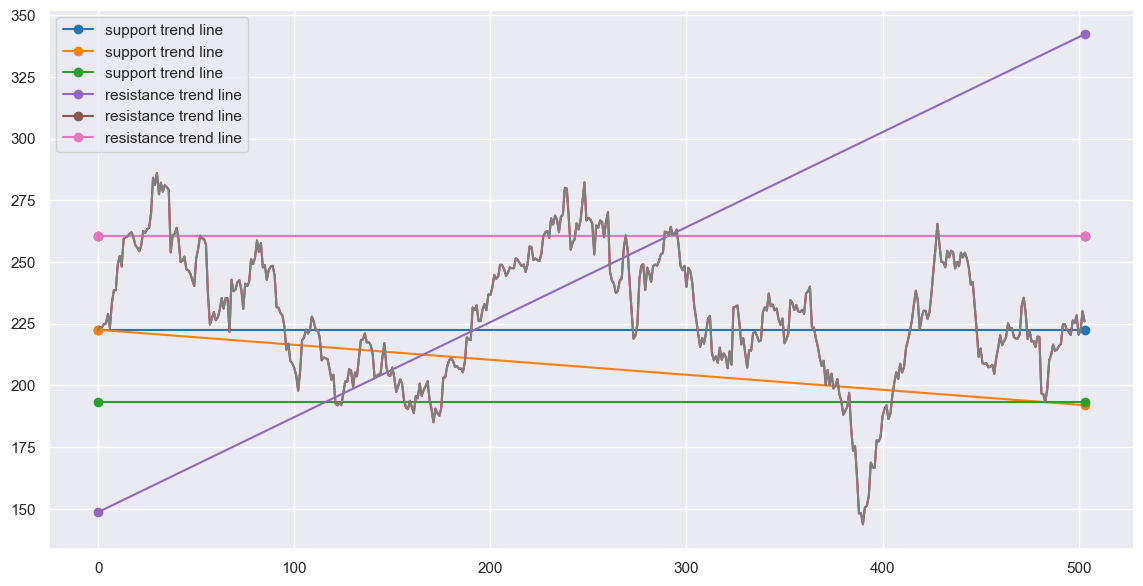

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from abupy import ABuSymbolPd
from abupy.TLineBu.ABuTLine import AbuTLine

kl = ABuSymbolPd.make_kl_df('usTSLA', n_folds=2)
line = AbuTLine(kl.close, 'usTSLA')
line.show_support_resistance_trend(only_last=False)
plt.show()


## 量化分析工具控件

**注意**：widget 按钮点完出的图，可能不在控件正下方，要**滚到 notebook 最底部**找——ipywidgets 7 + JupyterLab 4 捕获 figure 的位置不太稳定。如果上面那格图能出，说明 abu 没坏，只是 widget 显示位置问题。


In [4]:
from abupy import WidgetQuantTool
WidgetQuantTool().widget

## 其它界面

abu 还有几个独立 notebook，每个都是「跑一格出 UI」的形式，点链接打开：

- [📊 历史回测界面](abupy_ui/历史回测界面操作.ipynb)
- [🛠 量化分析工具（独立页）](abupy_ui/量化分析工具操作.ipynb)
- [🔎 股票基本信息查询](abupy_ui/股票基本信息查询.ipynb)
- [🧪 参数最优交叉验证](abupy_ui/参数最优交叉验证.ipynb)

**注意**：打开这些 notebook 后，**先运行本页的第一格** ←（启用离线数据），再切回去跑它们的 widget。否则它们会去连已下线的百度接口，结果空白。

教程：

- [📚 abupy_lecture/ 目录](abupy_lecture/) ·《量化交易之路》对应章节
- [📚 ipython/ 示例代码](ipython/)

---

### 进阶：想用最新行情数据？

abu 内置的百度/网易接口已死，腾讯接口 host 还活着但需要二次封装。最干净的做法是用 `akshare` / `yfinance` 拉数据，转成 abu 期望的 DataFrame 格式（列：`open/high/low/close/volume/p_change/pre_close/date/date_week/key/atr14/atr21`）。需要时告诉我。

### 关闭

直接关掉终端窗口（运行 `abu.command` 弹出的那个），JupyterLab 会随之退出。